In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import re
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier 
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support, 
                             confusion_matrix, classification_report)
from sklearn.preprocessing import LabelEncoder



In [2]:
# --- 1. DATA LOADING ---
print("Step 1: Loading datasets...")
train_df = pd.read_csv("KDDTrain.csv")
test_df = pd.read_csv("KDDTest.csv")

Step 1: Loading datasets...


In [3]:
print("Step 2: Cleaning data and fixing labels...")

y_train_raw = train_df['attack_type']
y_test_raw = test_df['attack_type']

Step 2: Cleaning data and fixing labels...


In [4]:
y_train_clean = y_train_raw.fillna('unknown').astype(str)
y_test_clean = y_test_raw.fillna('unknown').astype(str)

In [5]:
drop_cols = ['attack_type', 'difficulty_level']
X_train_raw = train_df.drop(columns=[c for c in drop_cols if c in train_df.columns])
X_test_raw = test_df.drop(columns=[c for c in drop_cols if c in test_df.columns])

In [6]:
drop_cols = ['attack_type', 'difficulty_level']
X_train_raw = train_df.drop(columns=[c for c in drop_cols if c in train_df.columns])
X_test_raw = test_df.drop(columns=[c for c in drop_cols if c in test_df.columns])

In [7]:
le = LabelEncoder()
le.fit(pd.concat([y_train_clean, y_test_clean]))
y_train = le.transform(y_train_clean)
y_test = le.transform(y_test_clean)

In [8]:
# Feature Encoding
combined_X = pd.concat([X_train_raw, X_test_raw], axis=0).fillna(0)
combined_X_encoded = pd.get_dummies(combined_X)

In [9]:
# --- FIX START: Clean column names for LightGBM compatibility ---
# This replaces [, ], <, >, :, and " with an underscore _
combined_X_encoded.columns = [re.sub(r'[\[\]<>,:"]', '_', col) for col in combined_X_encoded.columns]
print("Cleaned feature names for LightGBM compatibility.")

Cleaned feature names for LightGBM compatibility.


In [10]:
X_train = combined_X_encoded.iloc[:len(train_df)]
X_test = combined_X_encoded.iloc[len(train_df):]

In [11]:
# 5. HYBRID MODEL TRAINING
print("Step 4: Training Hybrid Model (XGB + LGBM)...")
xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, eval_metric='mlogloss', random_state=42)
lgbm = LGBMClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42, verbose=-1)

Step 4: Training Hybrid Model (XGB + LGBM)...


In [12]:
hybrid_model = VotingClassifier(
    estimators=[('xgb', xgb), ('lgbm', lgbm)],
    voting='soft'
)
hybrid_model.fit(X_train, y_train)

,estimators,"[('xgb', ...), ('lgbm', ...)]"
,voting,'soft'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None


In [13]:
# 6. METRICS & VISUALIZATION
print("Step 5: Evaluating...")
y_pred = hybrid_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
pre, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)

metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Score': [acc, pre, rec, f1]
})

print("\n--- Final Results ---")
print(metrics_df.to_string(index=False))

Step 5: Evaluating...

--- Final Results ---
   Metric    Score
 Accuracy 0.598696
Precision 0.397952
   Recall 0.598696
 F1-Score 0.476098


C:\Users\saadr\AppData\Local\Temp\ipykernel_3324\2993810343.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Metric', y='Score', data=metrics_df, palette='viridis')


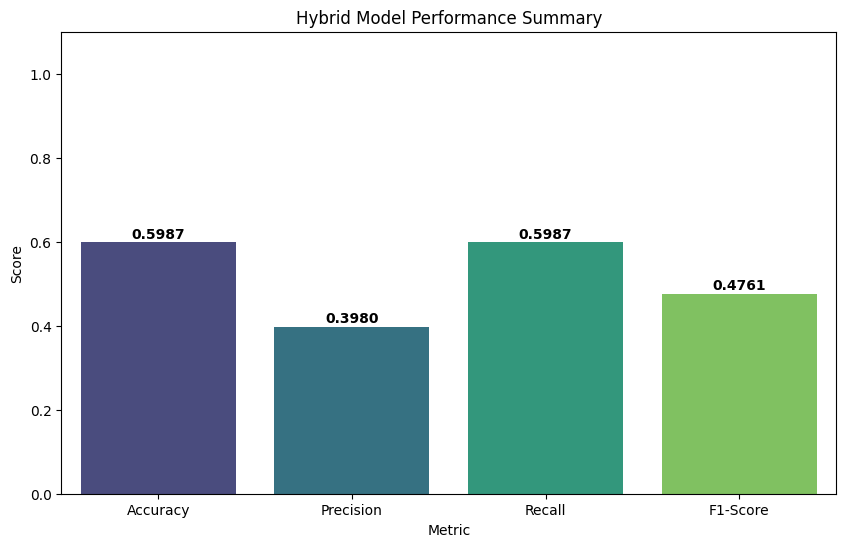

In [14]:
# Visualization
plt.figure(figsize=(10, 6))
sns.barplot(x='Metric', y='Score', data=metrics_df, palette='viridis')
plt.title("Hybrid Model Performance Summary")
plt.ylim(0, 1.1)
for i, v in enumerate(metrics_df['Score']):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center', fontweight='bold')
plt.show()

In [15]:
# 7. SAVE FOR FRONTEND
artifacts = {
    'model': hybrid_model,
    'features': combined_X_encoded.columns.tolist(),
    'label_encoder': le
}
joblib.dump(artifacts, 'hybrid_artifacts.joblib')
print("\nSuccess! 'hybrid_artifacts.joblib' is created and ready for Streamlit.")


Success! 'hybrid_artifacts.joblib' is created and ready for Streamlit.


In [16]:
joblib.dump(hybrid_model, 'hybrid_intrusion_model.joblib')
print("\nHybrid model saved successfully!")


Hybrid model saved successfully!
